# Busyness Prediction Model Training

**Goal:** Train and evaluate models using for predict zone-level busyness for the next 48 hours across Manhattan TLC Taxi Zones, in 30-minute intervals.

**Data sources:**
- NYC Yellow Taxi Trip Records 2025 (Parquet)
- NYC Green Taxi Trip Records 2025 (Parquet)
- NYC High Volume FHV (Uber/Lyft) Trip Records 2025 (Parquet)
- Open-Meteo Historical Weather API (hourly, 2025)

**Model:** LightGBM XGBoost CatBoost

---

### Notebook sections
1. Setup & imports
2. Fetch 2025 weather data
2. Download 2025 TLC trip data
3. Aggregate taxi trip data → target variable
4. Feature engineering
5. Train / validate / test split
6. Train LightGBM · XGBoost · CatBoost models
7. Evaluate & Compare: LightGBM vs XGBoost vs CatBoost vs Baseline
8. Summary

## 1. Setup & imports

In [2]:
# Install dependencies (run once)
# !pip install lightgbm xgboost catboost duckdb requests pandas numpy scikit-learn matplotlib seaborn holidays

import warnings
warnings.filterwarnings('ignore')

import os
import json
import requests
import numpy as np
import pandas as pd
import duckdb
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor, Pool
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# ── Paths ──────────────────────────────────────────────────────────────────
RAW_DIR    = Path('raw')          # parquet files here (gitignored)
OUTPUT_DIR = Path('output')       # CSVs and model artifacts
OUTPUT_DIR.mkdir(exist_ok=True)

print('Libraries loaded ✓')
print(f'LightGBM version : {lgb.__version__}')
print(f'XGBoost  version : {xgb.__version__}')
import catboost as cb
print(f'CatBoost version : {cb.__version__}')


Libraries loaded ✓
LightGBM version : 4.6.0
XGBoost  version : 3.2.0
CatBoost version : 1.2.10


## 2. Fetch 2025 weather data (Open-Meteo Historical API)

In [15]:
WEATHER_CSV = OUTPUT_DIR / 'weather_2025.csv'

if WEATHER_CSV.exists():
    print('Weather file already exists — loading from disk.')
    weather_df = pd.read_csv(WEATHER_CSV, parse_dates=['time'])
else:
    print('Fetching from Open-Meteo archive API...')
    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude':   40.7580,           # Manhattan centre
        'longitude': -73.9855,
        'start_date': '2025-01-01',
        'end_date':   '2025-12-31',
        'hourly':     'temperature_2m,precipitation,weathercode,windspeed_10m',
        'timezone':   'America/New_York'
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()['hourly']

    weather_df = pd.DataFrame(data)
    weather_df['time'] = pd.to_datetime(weather_df['time'])
    weather_df.rename(columns={'time': 'datetime'}, inplace=True)

    # Round to nearest hour for later merging
    weather_df['hour_bucket'] = weather_df['datetime'].dt.floor('h')

    weather_df.to_csv(WEATHER_CSV, index=False)
    print(f'Saved {len(weather_df):,} rows → {WEATHER_CSV}')

print(weather_df.head())
print(f'Shape: {weather_df.shape}')
print('\nAttribution: Weather data by Open-Meteo.com')

Fetching from Open-Meteo archive API...
Saved 8,760 rows → output/weather_2025.csv
             datetime  temperature_2m  precipitation  weathercode  \
0 2025-01-01 00:00:00             6.8            3.7           63   
1 2025-01-01 01:00:00             7.5            0.9           53   
2 2025-01-01 02:00:00             7.9            0.0            3   
3 2025-01-01 03:00:00             8.2            0.0            3   
4 2025-01-01 04:00:00             8.2            0.0            3   

   windspeed_10m         hour_bucket  
0           17.3 2025-01-01 00:00:00  
1           14.9 2025-01-01 01:00:00  
2            7.8 2025-01-01 02:00:00  
3            8.8 2025-01-01 03:00:00  
4            8.8 2025-01-01 04:00:00  
Shape: (8760, 6)

Attribution: Weather data by Open-Meteo.com


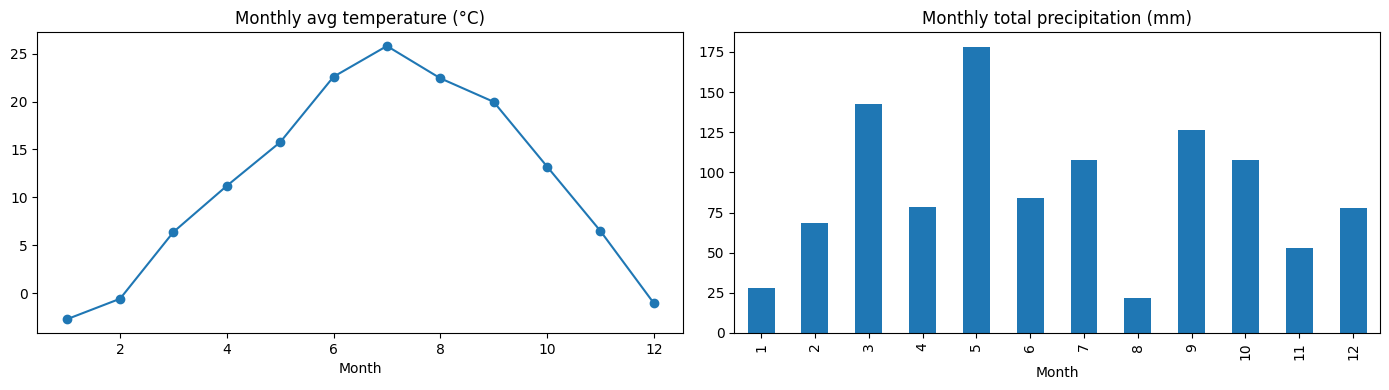

In [16]:
# Quick plot — monthly average temperature
weather_df['month'] = pd.to_datetime(weather_df['datetime']).dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

weather_df.groupby('month')['temperature_2m'].mean().plot(
    ax=axes[0], marker='o', title='Monthly avg temperature (°C)', xlabel='Month')

weather_df.groupby('month')['precipitation'].sum().plot(
    kind='bar', ax=axes[1], title='Monthly total precipitation (mm)', xlabel='Month')

plt.tight_layout()
plt.show()

## 3. Download 2025 TLC trip data

Downloads Yellow, Green, and High Volume FHV (Uber/Lyft) parquet files for all 12 months of 2025
into `raw/<dtype>/` subdirectories. Already-downloaded files are skipped automatically.

In [4]:
# ── TLC Download Configuration ──────────────────────────────────────────────
import urllib.request
import time

TLC_BASE_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data"
TLC_YEAR     = 2025
TLC_MONTHS   = range(1, 13)   # Jan–Dec

TLC_DATASETS = {
    "yellow": "yellow_tripdata",
    "green":  "green_tripdata",
    "hvfhv":  "fhvhv_tripdata",   # High Volume FHV (Uber/Lyft)
}

# RAW_DIR is already defined in Section 1 (Path('raw'))
RAW_DIR.mkdir(exist_ok=True)

def _fmt_size(b: int) -> str:
    for unit in ['B', 'KB', 'MB', 'GB']:
        if b < 1024:
            return f'{b:.1f} {unit}'
        b /= 1024
    return f'{b:.1f} TB'


def _download_parquet(url: str, dest: Path) -> str:
    """Download url → dest. Returns 'skipped', 'ok', or 'failed'."""
    if dest.exists():
        return 'skipped'
    dest.parent.mkdir(parents=True, exist_ok=True)
    tmp = dest.with_suffix('.tmp')
    try:
        print(f'  ⬇  {dest.name}', end='', flush=True)
        t0 = time.time()

        def _hook(blk, blk_sz, total):
            done = blk * blk_sz
            if total > 0:
                pct = min(done / total * 100, 100)
                print(f'\r  ⬇  {dest.name}  {pct:.0f}%  ({_fmt_size(done)}/{_fmt_size(total)})',
                      end='', flush=True)

        urllib.request.urlretrieve(url, tmp, _hook)
        tmp.rename(dest)
        elapsed = time.time() - t0
        print(f'\r  ✅ {dest.name}  ({_fmt_size(dest.stat().st_size)}, {elapsed:.1f}s)')
        return 'ok'
    except Exception as exc:
        print(f'\r  ❌ {dest.name}  — {exc}')
        if tmp.exists():
            tmp.unlink()
        return 'failed'


print('TLC download helpers ready ✓')
print(f'Raw data directory: {RAW_DIR.resolve()}')


TLC download helpers ready ✓
Raw data directory: /Users/rj/Desktop/dev/code/COMP47360 /ML/raw


In [5]:
# ── Run downloads ────────────────────────────────────────────────────────────
# Set SKIP_DOWNLOAD = True to bypass this cell if files already exist.
SKIP_DOWNLOAD = False

if SKIP_DOWNLOAD:
    print('SKIP_DOWNLOAD=True — skipping download step.')
else:
    results = {'ok': [], 'skipped': [], 'failed': []}

    for dtype, prefix in TLC_DATASETS.items():
        print(f'\n' + '='*55)
        print(f'📁  {dtype.upper()}  ({prefix})')
        print('='*55)
        for month in TLC_MONTHS:
            fname = f'{prefix}_{TLC_YEAR}-{month:02d}.parquet'
            url   = f'{TLC_BASE_URL}/{fname}'
            dest  = RAW_DIR / dtype / fname
            status = _download_parquet(url, dest)
            results[status].append(fname)

    # ── Summary ──────────────────────────────────────────────────────────────
    print(f'\n' + '='*55)
    print('📊  Download Summary')
    print('='*55)
    print(f'  ✅ Downloaded : {len(results["ok"])} file(s)')
    print(f'  ⏭  Skipped   : {len(results["skipped"])} file(s)  (already exist)')
    print(f'  ❌ Failed    : {len(results["failed"])} file(s)')
    if results['failed']:
        print('\n  Failed files:')
        for f in results['failed']:
            print(f'    - {f}')

    total_bytes = sum(
        f.stat().st_size
        for f in RAW_DIR.rglob('*.parquet') if f.exists()
    )
    print(f'\n💾  Total local disk usage: {_fmt_size(total_bytes)}')



📁  YELLOW  (yellow_tripdata)
  ⬇  yellow_tripdata_2025-01.parquet

  ✅ yellow_tripdata_2025-01.parquet  (56.4 MB, 6.7s)/56.4 MB)
  ✅ yellow_tripdata_2025-02.parquet  (57.5 MB, 6.6s)/57.5 MB)
  ✅ yellow_tripdata_2025-03.parquet  (66.7 MB, 8.3s)/66.7 MB)
  ✅ yellow_tripdata_2025-04.parquet  (64.2 MB, 5.6s)/64.2 MB)
  ✅ yellow_tripdata_2025-05.parquet  (74.2 MB, 7.8s)/74.2 MB)
  ✅ yellow_tripdata_2025-06.parquet  (70.1 MB, 6.7s)/70.1 MB)
  ✅ yellow_tripdata_2025-07.parquet  (63.8 MB, 5.8s)/63.8 MB)
  ✅ yellow_tripdata_2025-08.parquet  (59.4 MB, 7.0s)/59.4 MB)
  ✅ yellow_tripdata_2025-09.parquet  (69.1 MB, 8.6s)/69.1 MB)
  ✅ yellow_tripdata_2025-10.parquet  (71.8 MB, 8.6s)/71.8 MB)
  ✅ yellow_tripdata_2025-11.parquet  (67.8 MB, 9.0s)/67.8 MB)
  ✅ yellow_tripdata_2025-12.parquet  (70.3 MB, 11.5s)70.3 MB)

📁  GREEN  (green_tripdata)
  ✅ green_tripdata_2025-01.parquet  (1.1 MB, 0.9s)/1.1 MB)B)
  ✅ green_tripdata_2025-02.parquet  (1.1 MB, 0.2s)/1.1 MB)B)
  ✅ green_tripdata_2025-03.parquet  (1.2 MB, 0.3s)/1.2 MB)B)
  ✅ green_tripdata_2025-04.parquet  (1.2 MB, 

In [6]:
# ── Verify downloaded files ──────────────────────────────────────────────────
# Shows which months are available per dataset type.
for dtype, prefix in TLC_DATASETS.items():
    files = sorted((RAW_DIR / dtype).glob(f'{prefix}_{TLC_YEAR}-*.parquet')) \
            if (RAW_DIR / dtype).exists() else []
    months_found = [f.stem.split('-')[-1] for f in files]
    print(f'{dtype.upper():8s}: {len(files):2d}/12 months  {months_found}')


YELLOW  : 12/12 months  ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']
GREEN   : 12/12 months  ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']
HVFHV   : 12/12 months  ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']


## 4. Aggregate taxi trip data → target variable

In [7]:
# ── Manhattan zone IDs ─────────────────────────────────────────────────────
# Download the TLC zone lookup CSV to filter Manhattan only
ZONE_CSV = OUTPUT_DIR / 'taxi_zones.csv'

if not ZONE_CSV.exists():
    zone_url = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'
    zone_df = pd.read_csv(zone_url)
    zone_df.to_csv(ZONE_CSV, index=False)
else:
    zone_df = pd.read_csv(ZONE_CSV)

manhattan_zones = zone_df[zone_df['Borough'] == 'Manhattan']['LocationID'].tolist()
print(f'Manhattan zones: {len(manhattan_zones)} zones')
print(manhattan_zones[:10], '...')

Manhattan zones: 69 zones
[4, 12, 13, 24, 41, 42, 43, 45, 48, 50] ...


In [17]:
# ── Aggregate Yellow Taxi ──────────────────────────────────────────────────
# Expects: raw/yellow_tripdata_2025-*.parquet

YELLOW_PARQUETS = sorted((RAW_DIR / 'yellow').glob('yellow_tripdata_2025-*.parquet'))
print(f'Found {len(YELLOW_PARQUETS)} Yellow Taxi parquet files')

if YELLOW_PARQUETS:
    con = duckdb.connect()

    # Build zone filter string for DuckDB
    zone_list = ','.join(map(str, manhattan_zones))

    yellow_agg = con.execute(f"""
        SELECT
            DOLocationID AS zone_id,
            date_trunc('hour', tpep_dropoff_datetime)
                + INTERVAL (30 * (EXTRACT(MINUTE FROM tpep_dropoff_datetime)::INT / 30)) MINUTE
                AS time_bucket,
            COUNT(*) AS yellow_count
        FROM read_parquet({[str(p) for p in YELLOW_PARQUETS]})
        WHERE DOLocationID IN ({zone_list})
          AND tpep_dropoff_datetime >= '2025-01-01'
          AND tpep_dropoff_datetime <  '2026-01-01'
        GROUP BY 1, 2
        ORDER BY 1, 2
    """).df()

    yellow_agg['time_bucket'] = pd.to_datetime(yellow_agg['time_bucket'])
    yellow_agg.to_csv(OUTPUT_DIR / 'yellow_agg.csv', index=False)
    print(f'Yellow aggregated: {len(yellow_agg):,} rows')
    print(yellow_agg.head())
else:
    print('No Yellow Taxi parquet files found in raw/ — loading from saved CSV if available.')
    yellow_agg = pd.read_csv(OUTPUT_DIR / 'yellow_agg.csv', parse_dates=['time_bucket'])

Found 12 Yellow Taxi parquet files
Yellow aggregated: 17,197,728 rows
   zone_id         time_bucket  yellow_count
0        4 2025-01-01 00:10:00             1
1        4 2025-01-01 00:13:00             1
2        4 2025-01-01 00:16:00             1
3        4 2025-01-01 00:20:00             1
4        4 2025-01-01 00:25:00             1


In [18]:
# ── Aggregate FHVHV (Uber/Lyft) ────────────────────────────────────────────
# Expects: raw/fhvhv_tripdata_2025-*.parquet

FHVHV_PARQUETS = sorted((RAW_DIR / 'hvfhv').glob('fhvhv_tripdata_2025-*.parquet'))
print(f'Found {len(FHVHV_PARQUETS)} FHVHV parquet files')

if FHVHV_PARQUETS:
    con = duckdb.connect()
    zone_list = ','.join(map(str, manhattan_zones))

    fhvhv_agg = con.execute(f"""
        SELECT
            DOLocationID AS zone_id,
            date_trunc('hour', dropoff_datetime)
                + INTERVAL (30 * (EXTRACT(MINUTE FROM dropoff_datetime)::INT / 30)) MINUTE
                AS time_bucket,
            COUNT(*) AS fhvhv_count
        FROM read_parquet({[str(p) for p in FHVHV_PARQUETS]})
        WHERE DOLocationID IN ({zone_list})
          AND dropoff_datetime >= '2025-01-01'
          AND dropoff_datetime <  '2026-01-01'
        GROUP BY 1, 2
        ORDER BY 1, 2
    """).df()

    fhvhv_agg['time_bucket'] = pd.to_datetime(fhvhv_agg['time_bucket'])
    fhvhv_agg.to_csv(OUTPUT_DIR / 'fhvhv_agg.csv', index=False)
    print(f'FHVHV aggregated: {len(fhvhv_agg):,} rows')
    print(fhvhv_agg.head())
else:
    print('No FHVHV parquet files found — loading from saved CSV if available.')
    fhvhv_agg = pd.read_csv(OUTPUT_DIR / 'fhvhv_agg.csv', parse_dates=['time_bucket'])

Found 12 FHVHV parquet files
FHVHV aggregated: 25,031,832 rows
   zone_id         time_bucket  fhvhv_count
0        4 2025-01-01 00:12:00            1
1        4 2025-01-01 00:13:00            1
2        4 2025-01-01 00:15:00            2
3        4 2025-01-01 00:17:00            2
4        4 2025-01-01 00:18:00            4


In [9]:
# ── Aggregate Green Taxi (LPEP) ────────────────────────────────────────────
# Note: Green Taxi uses lpep_dropoff_datetime (not tpep_)
# Green Taxi mainly serves outer boroughs but some trips drop off in Manhattan
# Expects: raw/green_tripdata_2025-*.parquet

GREEN_PARQUETS = sorted((RAW_DIR / 'green').glob('green_tripdata_2025-*.parquet'))
print(f'Found {len(GREEN_PARQUETS)} Green Taxi parquet files')

if GREEN_PARQUETS:
    con = duckdb.connect()
    zone_list = ','.join(map(str, manhattan_zones))

    green_agg = con.execute(f"""
        SELECT
            DOLocationID AS zone_id,
            date_trunc('hour', lpep_dropoff_datetime)
                + INTERVAL (30 * (EXTRACT(MINUTE FROM lpep_dropoff_datetime)::INT / 30)) MINUTE
                AS time_bucket,
            COUNT(*) AS green_count
        FROM read_parquet({[str(p) for p in GREEN_PARQUETS]})
        WHERE DOLocationID IN ({zone_list})
          AND lpep_dropoff_datetime >= '2025-01-01'
          AND lpep_dropoff_datetime <  '2026-01-01'
        GROUP BY 1, 2
        ORDER BY 1, 2
    """).df()

    green_agg['time_bucket'] = pd.to_datetime(green_agg['time_bucket'])
    green_agg.to_csv(OUTPUT_DIR / 'green_agg.csv', index=False)
    print(f'Green aggregated: {len(green_agg):,} rows')
    print(green_agg.head())
else:
    print('No Green Taxi parquet files found in raw/ — loading from saved CSV if available.')
    green_agg = pd.read_csv(OUTPUT_DIR / 'green_agg.csv', parse_dates=['time_bucket'])

# Quick sanity check: how many Manhattan dropoffs does Green actually have?
print(f'\nTotal Green Manhattan dropoffs: {green_agg["green_count"].sum():,.0f}')
print(f'Unique zones with Green dropoffs: {green_agg["zone_id"].nunique()}')

Found 12 Green Taxi parquet files
Green aggregated: 345,485 rows
   zone_id         time_bucket  green_count
0        4 2025-01-01 16:00:00            1
1        4 2025-01-01 20:50:00            1
2        4 2025-01-02 12:53:00            1
3        4 2025-01-02 13:54:00            1
4        4 2025-01-03 18:30:00            1

Total Green Manhattan dropoffs: 357,029
Unique zones with Green dropoffs: 66


In [19]:
# ── Merge Yellow + Green + FHVHV ─────────────────────────────────────────
combined = (
    yellow_agg
    .merge(green_agg,  on=['zone_id', 'time_bucket'], how='outer')
    .merge(fhvhv_agg,  on=['zone_id', 'time_bucket'], how='outer')
    .fillna(0)
)

combined['total_dropoffs'] = (
    combined['yellow_count'] +
    combined['green_count']  +
    combined['fhvhv_count']
)
combined = combined.sort_values(['zone_id', 'time_bucket']).reset_index(drop=True)

combined.to_csv(OUTPUT_DIR / 'combined_dropoffs.csv', index=False)
print(f'Combined dataset: {len(combined):,} rows')
print(combined.head(10))

# Contribution breakdown
total = combined['total_dropoffs'].sum()
print(f'\nDropoff contribution:')
print(f'  Yellow : {combined["yellow_count"].sum() / total * 100:.1f}%')
print(f'  Green  : {combined["green_count"].sum()  / total * 100:.1f}%')
print(f'  FHVHV  : {combined["fhvhv_count"].sum() / total * 100:.1f}%')
print(f'\nDate range: {combined.time_bucket.min()} → {combined.time_bucket.max()}')
print(f'Unique zones: {combined.zone_id.nunique()}')
print(f'Avg dropoffs per slot: {combined.total_dropoffs.mean():.1f}')

Combined dataset: 26,918,772 rows
   zone_id         time_bucket  yellow_count  green_count  fhvhv_count  \
0        4 2025-01-01 00:10:00           1.0          0.0          0.0   
1        4 2025-01-01 00:12:00           0.0          0.0          1.0   
2        4 2025-01-01 00:13:00           1.0          0.0          1.0   
3        4 2025-01-01 00:15:00           0.0          0.0          2.0   
4        4 2025-01-01 00:16:00           1.0          0.0          0.0   
5        4 2025-01-01 00:17:00           0.0          0.0          2.0   
6        4 2025-01-01 00:18:00           0.0          0.0          4.0   
7        4 2025-01-01 00:19:00           0.0          0.0          1.0   
8        4 2025-01-01 00:20:00           1.0          0.0          1.0   
9        4 2025-01-01 00:21:00           0.0          0.0          1.0   

   total_dropoffs  
0             1.0  
1             1.0  
2             2.0  
3             2.0  
4             1.0  
5             2.0  
6          

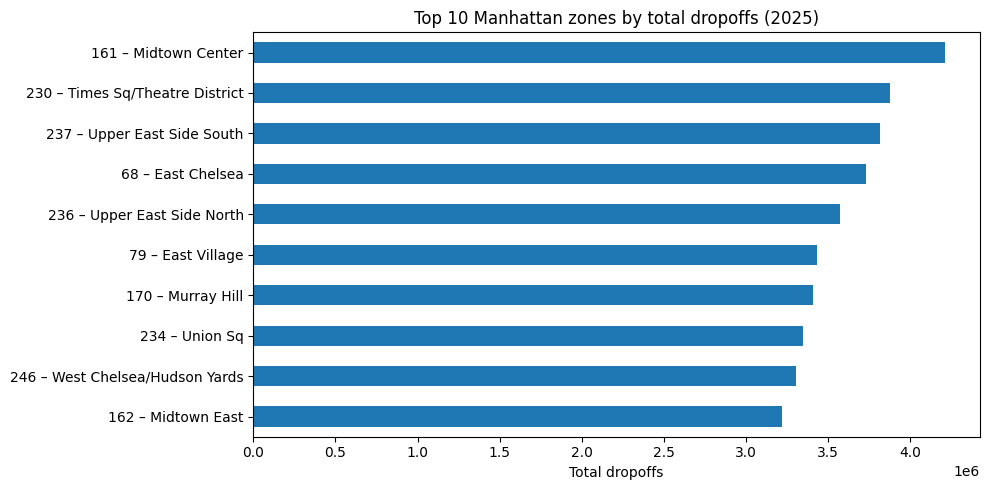

In [20]:
# ── Visualise top 10 busiest zones ────────────────────────────────────────
top_zones = (
    combined.groupby('zone_id')['total_dropoffs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Map zone IDs to names
id_to_name = zone_df.set_index('LocationID')['Zone'].to_dict()
top_zones.index = [f"{i} – {id_to_name.get(i, '?')}" for i in top_zones.index]

fig, ax = plt.subplots(figsize=(10, 5))
top_zones.sort_values().plot(kind='barh', ax=ax, title='Top 10 Manhattan zones by total dropoffs (2025)')
ax.set_xlabel('Total dropoffs')
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd

df = pd.read_csv("output/combined_dropoffs.csv")

total_rows = len(df)
duplicate_mask = df.duplicated()
n_duplicates = duplicate_mask.sum()

print(f"Total rows:        {total_rows:,}")
print(f"Duplicate rows:    {n_duplicates:,}")
print(f"Duplicate ratio:   {n_duplicates / total_rows:.2%}")
print(f"Rows after dedup:  {total_rows - n_duplicates:,}")

Total rows:        26,918,772
Duplicate rows:    0
Duplicate ratio:   0.00%
Rows after dedup:  26,918,772


## 5. Feature engineering

In [5]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path('output')

combined = pd.read_csv(OUTPUT_DIR / 'combined_dropoffs.csv', parse_dates=['time_bucket'])
print(f'combined loaded: {len(combined):,} rows')

weather_df = pd.read_csv(OUTPUT_DIR / 'weather_2025.csv', parse_dates=['datetime', 'hour_bucket'])
print(f'weather_df loaded: {len(weather_df):,} rows')

combined loaded: 26,918,772 rows
weather_df loaded: 8,760 rows


In [6]:
df = combined.copy()

# ── Time features ──────────────────────────────────────────────────────────
df['hour']         = df['time_bucket'].dt.hour
df['minute']       = df['time_bucket'].dt.minute
df['slot_of_day']  = df['hour'] * 2 + (df['minute'] >= 30).astype(int)  # 0–47
df['dayofweek']    = df['time_bucket'].dt.dayofweek   # 0=Mon, 6=Sun
df['is_weekend']   = (df['dayofweek'] >= 5).astype(int)
df['month']        = df['time_bucket'].dt.month
df['dayofyear']    = df['time_bucket'].dt.dayofyear
df['weekofyear']   = df['time_bucket'].dt.isocalendar().week.astype(int)

# Cyclical encoding — avoids 23→0 discontinuity
df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin']   = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['dayofweek'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# US public holidays
us_holidays = holidays.US(state='NY', years=2025)
df['is_holiday'] = df['time_bucket'].dt.date.apply(lambda d: int(d in us_holidays))

print('Time features added ✓')
print(df[['time_bucket','hour','slot_of_day','dayofweek','is_weekend','is_holiday']].head(6))

Time features added ✓
          time_bucket  hour  slot_of_day  dayofweek  is_weekend  is_holiday
0 2025-01-01 00:10:00     0            0          2           0           1
1 2025-01-01 00:12:00     0            0          2           0           1
2 2025-01-01 00:13:00     0            0          2           0           1
3 2025-01-01 00:15:00     0            0          2           0           1
4 2025-01-01 00:16:00     0            0          2           0           1
5 2025-01-01 00:17:00     0            0          2           0           1


In [7]:
# ── Lag features (same slot, N weeks ago) ─────────────────────────────────
# Sort before computing lags
df = df.sort_values(['zone_id', 'time_bucket']).reset_index(drop=True)

SLOTS_PER_WEEK = 7 * 48   # 336 slots

for lag_weeks in [1, 2, 3]:
    lag_n = lag_weeks * SLOTS_PER_WEEK
    df[f'lag_{lag_weeks}w'] = (
        df.groupby('zone_id')['total_dropoffs']
          .shift(lag_n)
    )

# 4-week rolling mean at same slot
df['rolling_mean_4w'] = (
    df.groupby('zone_id')['total_dropoffs']
      .shift(SLOTS_PER_WEEK)
      .rolling(window=4 * SLOTS_PER_WEEK, min_periods=1)
      .mean()
      .values
)

print('Lag features added ✓')
print(df[['zone_id','time_bucket','total_dropoffs','lag_1w','lag_2w','lag_3w','rolling_mean_4w']].dropna().head(6))

Lag features added ✓
      zone_id         time_bucket  total_dropoffs  lag_1w  lag_2w  lag_3w  \
1008        4 2025-01-01 23:39:00             2.0     1.0     5.0     1.0   
1009        4 2025-01-01 23:41:00             4.0     1.0     2.0     1.0   
1010        4 2025-01-01 23:43:00             2.0     1.0     1.0     2.0   
1011        4 2025-01-01 23:44:00             2.0     3.0     1.0     2.0   
1012        4 2025-01-01 23:45:00             1.0     1.0     1.0     1.0   
1013        4 2025-01-01 23:47:00             1.0     1.0     1.0     2.0   

      rolling_mean_4w  
1008         2.910847  
1009         2.908012  
1010         2.905185  
1011         2.905325  
1012         2.902511  
1013         2.899705  


In [8]:
# ── Merge weather features ────────────────────────────────────────────────
# Weather is hourly; join on floor(time_bucket, 'H')
weather_df['hour_bucket'] = pd.to_datetime(weather_df['datetime']).dt.floor('h')
df['hour_bucket'] = df['time_bucket'].dt.floor('h')

df = df.merge(
    weather_df[['hour_bucket','temperature_2m','precipitation','weathercode','windspeed_10m']],
    on='hour_bucket',
    how='left'
)

# Binary rain flag
df['is_raining'] = (df['precipitation'] > 0.2).astype(int)

print('Weather features merged ✓')
print(df[['time_bucket','temperature_2m','precipitation','is_raining']].head(6))

Weather features merged ✓
          time_bucket  temperature_2m  precipitation  is_raining
0 2025-01-01 00:10:00             6.8            3.7           1
1 2025-01-01 00:12:00             6.8            3.7           1
2 2025-01-01 00:13:00             6.8            3.7           1
3 2025-01-01 00:15:00             6.8            3.7           1
4 2025-01-01 00:16:00             6.8            3.7           1
5 2025-01-01 00:17:00             6.8            3.7           1


In [9]:
# ── Final feature set ─────────────────────────────────────────────────────
FEATURE_COLS = [
    'zone_id',
    # Time
    'slot_of_day', 'dayofweek', 'is_weekend', 'month', 'is_holiday',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    # Lags
    'lag_1w', 'lag_2w', 'lag_3w', 'rolling_mean_4w',
    # Weather
    'temperature_2m', 'precipitation', 'weathercode', 'windspeed_10m', 'is_raining',
]

TARGET_COL = 'total_dropoffs'

# Drop rows where lag features are NaN (first 3 weeks per zone)
df_model = df[FEATURE_COLS + [TARGET_COL, 'time_bucket']].dropna().copy()

print(f'Rows after dropping NaN lags: {len(df_model):,}')
print(f'Feature count: {len(FEATURE_COLS)}')
print(df_model[FEATURE_COLS].dtypes)

Rows after dropping NaN lags: 26,852,150
Feature count: 21
zone_id              int64
slot_of_day          int64
dayofweek            int32
is_weekend           int64
month                int32
is_holiday           int64
hour_sin           float64
hour_cos           float64
dow_sin            float64
dow_cos            float64
month_sin          float64
month_cos          float64
lag_1w             float64
lag_2w             float64
lag_3w             float64
rolling_mean_4w    float64
temperature_2m     float64
precipitation      float64
weathercode          int64
windspeed_10m      float64
is_raining           int64
dtype: object


In [13]:
df_model.to_csv(OUTPUT_DIR / 'df_model.csv', index=False)
print(f'Saved df_model → {OUTPUT_DIR / "df_model.csv"}')

Saved df_model → output/df_model.csv


In [ ]:
# df_model = pd.read_csv(OUTPUT_DIR / 'df_model.csv', parse_dates=['time_bucket'])
# print(f'df_model loaded: {len(df_model):,} rows')

## 6. Train / Validation / Test split (time-based)

In [14]:
# IMPORTANT: never shuffle time-series data
TRAIN_END = '2025-09-30 23:59:59'
VAL_END   = '2025-11-30 23:59:59'
# Test = December 2025

train = df_model[df_model['time_bucket'] <= TRAIN_END]
val   = df_model[(df_model['time_bucket'] > TRAIN_END) & (df_model['time_bucket'] <= VAL_END)]
test  = df_model[df_model['time_bucket'] > VAL_END]

X_train, y_train = train[FEATURE_COLS], train[TARGET_COL]
X_val,   y_val   = val[FEATURE_COLS],   val[TARGET_COL]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET_COL]

print(f'Train: {len(X_train):>10,} rows  ({train.time_bucket.min().date()} → {train.time_bucket.max().date()})')
print(f'Val  : {len(X_val):>10,} rows  ({val.time_bucket.min().date()} → {val.time_bucket.max().date()})')
print(f'Test : {len(X_test):>10,} rows  ({test.time_bucket.min().date()} → {test.time_bucket.max().date()})')

Train: 20,035,499 rows  (2025-01-01 → 2025-09-30)
Val  :  4,544,866 rows  (2025-10-01 → 2025-11-30)
Test :  2,271,785 rows  (2025-12-01 → 2025-12-31)


## 7. Train Models: LightGBM · XGBoost · CatBoost (static — train once, deploy forever)

All three models are trained offline on the same feature set and saved to `output/`.

**Artifacts saved:**
- `output/lgb_model.txt` — LightGBM model
- `output/xgb_model.ubj` — XGBoost model 
- `output/cat_model.cbm` — CatBoost model
- `output/feature_cols.json` — ordered feature list (must match at inference time)
- `output/model_metadata.json` — training metadata for all three models

In [32]:
import time

lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=['zone_id'])
lgb_val   = lgb.Dataset(X_val,   label=y_val,   reference=lgb_train, categorical_feature=['zone_id'])

params = {
    'objective':         'regression',
    'metric':            'mae',
    'learning_rate':     0.05,
    'num_leaves':        127,
    'max_depth':         -1,
    'min_child_samples': 50,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'reg_alpha':         0.1,
    'reg_lambda':        0.1,
    'verbose':           -1,
    'n_jobs':            -1,
    'seed':              42,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100)
]

t0 = time.time()
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=2000,
    valid_sets=[lgb_val],
    callbacks=callbacks
)
train_secs = time.time() - t0
print(f'Training time: {train_secs:.0f}s  |  Best iteration: {model.best_iteration}')

# ── Save model ────────────────────────────────────────────────────────────
MODEL_PATH    = OUTPUT_DIR / 'lgb_model.txt'
FEAT_PATH     = OUTPUT_DIR / 'feature_cols.json'
METADATA_PATH = OUTPUT_DIR / 'model_metadata.json'

# 1. LightGBM native format — load with lgb.Booster(model_file=...)
model.save_model(str(MODEL_PATH))

# 2. Feature column order — MUST match at inference time
import json as _json
with open(FEAT_PATH, 'w') as f:
    _json.dump(FEATURE_COLS, f, indent=2)

# 3. Metadata for traceability
from datetime import datetime as _dt
val_mae = float(np.mean(np.abs(y_val.values - model.predict(X_val, num_iteration=model.best_iteration))))
metadata = {
    'trained_at':       _dt.now().isoformat(),
    'best_iteration':   model.best_iteration,
    'val_mae':          round(val_mae, 4),
    'train_rows':       len(X_train),
    'train_period':     f'{train.time_bucket.min().date()} → {train.time_bucket.max().date()}',
    'val_period':       f'{val.time_bucket.min().date()} → {val.time_bucket.max().date()}',
    'test_period':      f'{test.time_bucket.min().date()} → {test.time_bucket.max().date()}',
    'features':         FEATURE_COLS,
    'lgbm_params':      params,
    'data_sources':     ['Yellow Taxi 2025', 'Green Taxi 2025', 'FHVHV 2025', 'Open-Meteo 2025'],
}
with open(METADATA_PATH, 'w') as f:
    _json.dump(metadata, f, indent=2)

print(f'\nModel saved       → {MODEL_PATH}')
print(f'Feature list saved → {FEAT_PATH}')
print(f'Metadata saved    → {METADATA_PATH}')
print(f'Val MAE: {val_mae:.2f} dropoffs')

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 1.67347
[200]	valid_0's l1: 1.65636
[300]	valid_0's l1: 1.65217
[400]	valid_0's l1: 1.64972
[500]	valid_0's l1: 1.648
[600]	valid_0's l1: 1.64648
[700]	valid_0's l1: 1.64529
[800]	valid_0's l1: 1.64451
[900]	valid_0's l1: 1.64396
[1000]	valid_0's l1: 1.64363
Early stopping, best iteration is:
[1024]	valid_0's l1: 1.6436
Training time: 605s  |  Best iteration: 1024

Model saved       → output/lgb_model.txt
Feature list saved → output/feature_cols.json
Metadata saved    → output/model_metadata.json
Val MAE: 1.64 dropoffs


In [33]:
# ── Verify: load model from disk and confirm identical predictions ─────────
# This is exactly how Spring Boot (via a Python sidecar or pre-computed table) will use it.

loaded_model = lgb.Booster(model_file=str(MODEL_PATH))

# Load feature list from JSON to guarantee column order
import json as _json
with open(FEAT_PATH) as f:
    loaded_features = _json.load(f)

# Load metadata
with open(METADATA_PATH) as f:
    meta = _json.load(f)

# Predict on a small sample using the loaded model
sample_pred_original = model.predict(X_val.head(5), num_iteration=model.best_iteration)
sample_pred_loaded   = loaded_model.predict(X_val[loaded_features].head(5))

match = np.allclose(sample_pred_original, sample_pred_loaded, atol=1e-6)
print(f'Predictions match after reload: {match} ✓' if match else '⚠ Mismatch — check feature order!')
print(f'\nModel metadata:')
print(f'  Trained at   : {meta["trained_at"]}')
print(f'  Best iter    : {meta["best_iteration"]}')
print(f'  Val MAE      : {meta["val_mae"]} dropoffs')
print(f'  Train period : {meta["train_period"]}')
print(f'  Data sources : {", ".join(meta["data_sources"])}')


Predictions match after reload: True ✓

Model metadata:
  Trained at   : 2026-06-01T16:35:45.826091
  Best iter    : 1024
  Val MAE      : 1.6436 dropoffs
  Train period : 2025-01-01 → 2025-09-30
  Data sources : Yellow Taxi 2025, Green Taxi 2025, FHVHV 2025, Open-Meteo 2025


In [36]:
# ── Train XGBoost ────────────────────────────────────────────────────────
import time

# XGBoost uses integer-encoded categoricals — zone_id is already int, no extra encoding needed
xgb_params = {
    'objective':        'reg:absoluteerror',   # MAE objective (matches LGB)
    'eval_metric':      'mae',
    'learning_rate':    0.05,
    'max_depth':        8,
    'min_child_weight': 50,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       0.1,
    'n_estimators':     2000,
    'early_stopping_rounds': 50,
    'verbosity':        0,
    'n_jobs':           -1,
    'random_state':     42,
    'tree_method':      'hist',    # fast histogram method
    'enable_categorical': True,    # treat zone_id as categorical
}

# Convert zone_id to pandas Categorical so XGBoost recognises it
X_train_xgb = X_train.copy()
X_val_xgb   = X_val.copy()
X_test_xgb  = X_test.copy()
for df_ in [X_train_xgb, X_val_xgb, X_test_xgb]:
    df_['zone_id'] = df_['zone_id'].astype('category')

xgb_model = xgb.XGBRegressor(**xgb_params)

t0 = time.time()
xgb_model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=100
)
xgb_secs = time.time() - t0

XGB_MODEL_PATH = OUTPUT_DIR / 'xgb_model.ubj'
xgb_model.save_model(str(XGB_MODEL_PATH))

xgb_val_mae = mean_absolute_error(y_val, np.clip(xgb_model.predict(X_val_xgb), 0, None))
print(f'Training time: {xgb_secs:.0f}s  |  Best iteration: {xgb_model.best_iteration}')
print(f'XGBoost Val MAE: {xgb_val_mae:.2f} dropoffs')
print(f'Model saved → {XGB_MODEL_PATH}')


[0]	validation_0-mae:2.71764
[100]	validation_0-mae:1.67418
[200]	validation_0-mae:1.64824
[300]	validation_0-mae:1.64343
[400]	validation_0-mae:1.64036
[500]	validation_0-mae:1.63718
[600]	validation_0-mae:1.63455
[700]	validation_0-mae:1.63276
[800]	validation_0-mae:1.63178
[900]	validation_0-mae:1.63084
[1000]	validation_0-mae:1.63039
[1100]	validation_0-mae:1.62986
[1200]	validation_0-mae:1.62929
[1300]	validation_0-mae:1.62857
[1400]	validation_0-mae:1.62819
[1500]	validation_0-mae:1.62781
[1600]	validation_0-mae:1.62752
[1700]	validation_0-mae:1.62725
[1800]	validation_0-mae:1.62707
[1900]	validation_0-mae:1.62672
[1999]	validation_0-mae:1.62655
Training time: 28970s  |  Best iteration: 1962
XGBoost Val MAE: 1.63 dropoffs
Model saved → output/xgb_model.ubj


In [15]:
# ── Train CatBoost ───────────────────────────────────────────────────────
import time
from catboost import Pool, CatBoostRegressor

CAT_FEATURES = ['zone_id']   # CatBoost handles categorical features natively

cat_params = {
    'loss_function':       'MAE',
    'eval_metric':         'MAE',
    'learning_rate':       0.05,
    'depth':               8,
    'min_data_in_leaf':    50,
    'subsample':           0.8,
    'rsm':                 0.8,     # colsample equivalent
    'l2_leaf_reg':         0.1,
    'iterations':          2000,
    'early_stopping_rounds': 50,
    'verbose':             100,
    'random_seed':         42,
    'thread_count':        -1,
    'cat_features':        CAT_FEATURES,
    'task_type':           'CPU',
}

train_pool = Pool(X_train, label=y_train, cat_features=CAT_FEATURES)
val_pool   = Pool(X_val,   label=y_val,   cat_features=CAT_FEATURES)

cat_model = CatBoostRegressor(**cat_params)

t0 = time.time()
cat_model.fit(train_pool, eval_set=val_pool, use_best_model=True)
cat_secs = time.time() - t0

CAT_MODEL_PATH = OUTPUT_DIR / 'cat_model.cbm'
cat_model.save_model(str(CAT_MODEL_PATH))

cat_val_mae = mean_absolute_error(y_val, np.clip(cat_model.predict(X_val), 0, None))
print(f'Training time: {cat_secs:.0f}s  |  Best iteration: {cat_model.best_iteration_}')
print(f'CatBoost Val MAE: {cat_val_mae:.2f} dropoffs')
print(f'Model saved → {CAT_MODEL_PATH}')


0:	learn: 2.6006849	test: 2.7317731	best: 2.7317731 (0)	total: 4.84s	remaining: 2h 41m 24s
100:	learn: 1.7440316	test: 1.8181669	best: 1.8181669 (100)	total: 6m 9s	remaining: 1h 55m 51s
200:	learn: 1.6809866	test: 1.7536564	best: 1.7536564 (200)	total: 12m 57s	remaining: 1h 55m 54s
300:	learn: 1.6472811	test: 1.7220816	best: 1.7220816 (300)	total: 19m 32s	remaining: 1h 50m 18s
400:	learn: 1.6278637	test: 1.7048308	best: 1.7048308 (400)	total: 25m 40s	remaining: 1h 42m 21s
500:	learn: 1.6168551	test: 1.6952644	best: 1.6952487 (499)	total: 31m 46s	remaining: 1h 35m 5s
600:	learn: 1.6083936	test: 1.6877153	best: 1.6877153 (600)	total: 38m 17s	remaining: 1h 29m 9s
700:	learn: 1.6030104	test: 1.6825120	best: 1.6824841 (690)	total: 44m 59s	remaining: 1h 23m 22s
800:	learn: 1.5965561	test: 1.6766207	best: 1.6766207 (800)	total: 52m 16s	remaining: 1h 18m 15s
900:	learn: 1.5909941	test: 1.6717265	best: 1.6717265 (900)	total: 58m 54s	remaining: 1h 11m 51s
1000:	learn: 1.5865483	test: 1.6679953	b

## 8. Evaluate & Compare: LightGBM vs XGBoost vs CatBoost vs Baseline

In [17]:
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
from pathlib import Path

OUTPUT_DIR = Path('output')

# Reload all three models from disk
model = lgb.Booster(model_file=str(OUTPUT_DIR / 'lgb_model.txt'))

xgb_model = xgb.XGBRegressor()
xgb_model.load_model(str(OUTPUT_DIR / 'xgb_model.ubj'))

cat_model = CatBoostRegressor()
cat_model.load_model(str(OUTPUT_DIR / 'cat_model.cbm'))

print('All three models loaded ✓')

All three models loaded ✓


In [20]:
import pandas as pd
import numpy as np

df_model = pd.read_csv(OUTPUT_DIR / 'df_model.csv', parse_dates=['time_bucket'])

TRAIN_END = pd.Timestamp('2025-08-31')
VAL_END   = pd.Timestamp('2025-10-31')

FEATURE_COLS = [c for c in df_model.columns if c not in ['time_bucket', 'total_dropoffs']]
TARGET_COL   = 'total_dropoffs'

train = df_model[df_model['time_bucket'] <= TRAIN_END]
val   = df_model[(df_model['time_bucket'] > TRAIN_END) & (df_model['time_bucket'] <= VAL_END)]
test  = df_model[df_model['time_bucket'] > VAL_END]

X_train, y_train = train[FEATURE_COLS], train[TARGET_COL]
X_val,   y_val   = val[FEATURE_COLS],   val[TARGET_COL]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET_COL]

# XGBoost needs label-encoded zone_id
X_val_xgb  = X_val.copy()
X_test_xgb = X_test.copy()
for df_ in [X_val_xgb, X_test_xgb]:
    df_['zone_id'] = df_['zone_id'].astype(int)

print('Data restored ✓')

Data restored ✓


In [23]:
# ── Predictions from all three models ───────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# LightGBM
y_pred_lgb_val  = np.clip(model.predict(X_val,  num_iteration=model.best_iteration), 0, None)
y_pred_lgb_test = np.clip(model.predict(X_test, num_iteration=model.best_iteration), 0, None)

# XGBoost — use DMatrix to bypass inplace_predict bug
dval  = xgb.DMatrix(X_val_xgb)
dtest = xgb.DMatrix(X_test_xgb)
y_pred_xgb_val  = np.clip(xgb_model.get_booster().predict(dval),  0, None)
y_pred_xgb_test = np.clip(xgb_model.get_booster().predict(dtest), 0, None)

# CatBoost
y_pred_cat_val  = np.clip(cat_model.predict(X_val),  0, None)
y_pred_cat_test = np.clip(cat_model.predict(X_test), 0, None)

# Baseline: 4-week rolling mean
baseline_val  = X_val['rolling_mean_4w'].fillna(0).values
baseline_test = X_test['rolling_mean_4w'].fillna(0).values

# ── Build comparison table: MAE / RMSE / R² (global) ─────────────────────
records = []
for split, y_true, preds in [
    ('Validation', y_val.values,  [y_pred_lgb_val,  y_pred_xgb_val,  y_pred_cat_val,  baseline_val]),
    ('Test',       y_test.values, [y_pred_lgb_test, y_pred_xgb_test, y_pred_cat_test, baseline_test]),
]:
    for model_name, y_pred in zip(
        ['LightGBM', 'XGBoost', 'CatBoost', 'Baseline (4w mean)'], preds
    ):
        records.append({
            'Split':      split,
            'Model':      model_name,
            'MAE':        round(mean_absolute_error(y_true, y_pred), 2),
            'RMSE':       round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
            'R² (global)': round(r2_score(y_true, y_pred), 4),
        })

results = pd.DataFrame(records)
print(results.to_string(index=False))
print()
print('Note: global R² is dominated by high-volume zones — see per-zone R² below.')
results.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
print('Saved → output/model_comparison.csv')

     Split              Model  MAE  RMSE  R² (global)
Validation           LightGBM 1.59  2.18       0.6603
Validation            XGBoost 4.38  5.30      -1.0086
Validation           CatBoost 1.60  2.27       0.6335
Validation Baseline (4w mean) 2.36  3.23       0.2546
      Test           LightGBM 1.69  2.35       0.6264
      Test            XGBoost 4.50  5.46      -1.0076
      Test           CatBoost 1.68  2.40       0.6116
      Test Baseline (4w mean) 2.40  3.30       0.2656

Note: global R² is dominated by high-volume zones — see per-zone R² below.
Saved → output/model_comparison.csv


In [24]:
# ── Per-zone R² distribution (Test set) ─────────────────────────────────
# Global R² can look great while underperforming on low-volume zones.
# Per-zone R² reveals where each model actually struggles.

zone_r2_records = []
test_copy = test[['zone_id', 'total_dropoffs']].copy().reset_index(drop=True)
test_copy['lgb_pred'] = y_pred_lgb_test
test_copy['xgb_pred'] = y_pred_xgb_test
test_copy['cat_pred'] = y_pred_cat_test
test_copy['base_pred'] = baseline_test

for model_name, pred_col in [
    ('LightGBM', 'lgb_pred'),
    ('XGBoost',  'xgb_pred'),
    ('CatBoost', 'cat_pred'),
    ('Baseline', 'base_pred'),
]:
    r2_series = (
        test_copy.groupby('zone_id')
        .apply(lambda g: r2_score(g['total_dropoffs'], g[pred_col])
               if len(g) > 1 else np.nan)
    )
    zone_r2_records.append({
        'Model':    model_name,
        'R² median':  round(r2_series.median(), 4),
        'R² mean':    round(r2_series.mean(),   4),
        'R² min':     round(r2_series.min(),    4),
        'R² < 0 (zones)': int((r2_series < 0).sum()),   # negative R² = worse than mean predictor
        'R² > 0.9 (zones)': int((r2_series > 0.9).sum()),
    })

zone_r2_df = pd.DataFrame(zone_r2_records)
print('Per-zone R² summary (Test set):')
print(zone_r2_df.to_string(index=False))
zone_r2_df.to_csv(OUTPUT_DIR / 'per_zone_r2.csv', index=False)
print('\nSaved → output/per_zone_r2.csv')


Per-zone R² summary (Test set):
   Model  R² median  R² mean     R² min  R² < 0 (zones)  R² > 0.9 (zones)
LightGBM     0.3559   0.3258    -0.9647               2                 0
 XGBoost    -2.7905 -37.5373 -1306.7511              61                 0
CatBoost     0.3150   0.3100    -0.1971               7                 0
Baseline     0.0098   0.0147    -0.0887              23                 0

Saved → output/per_zone_r2.csv


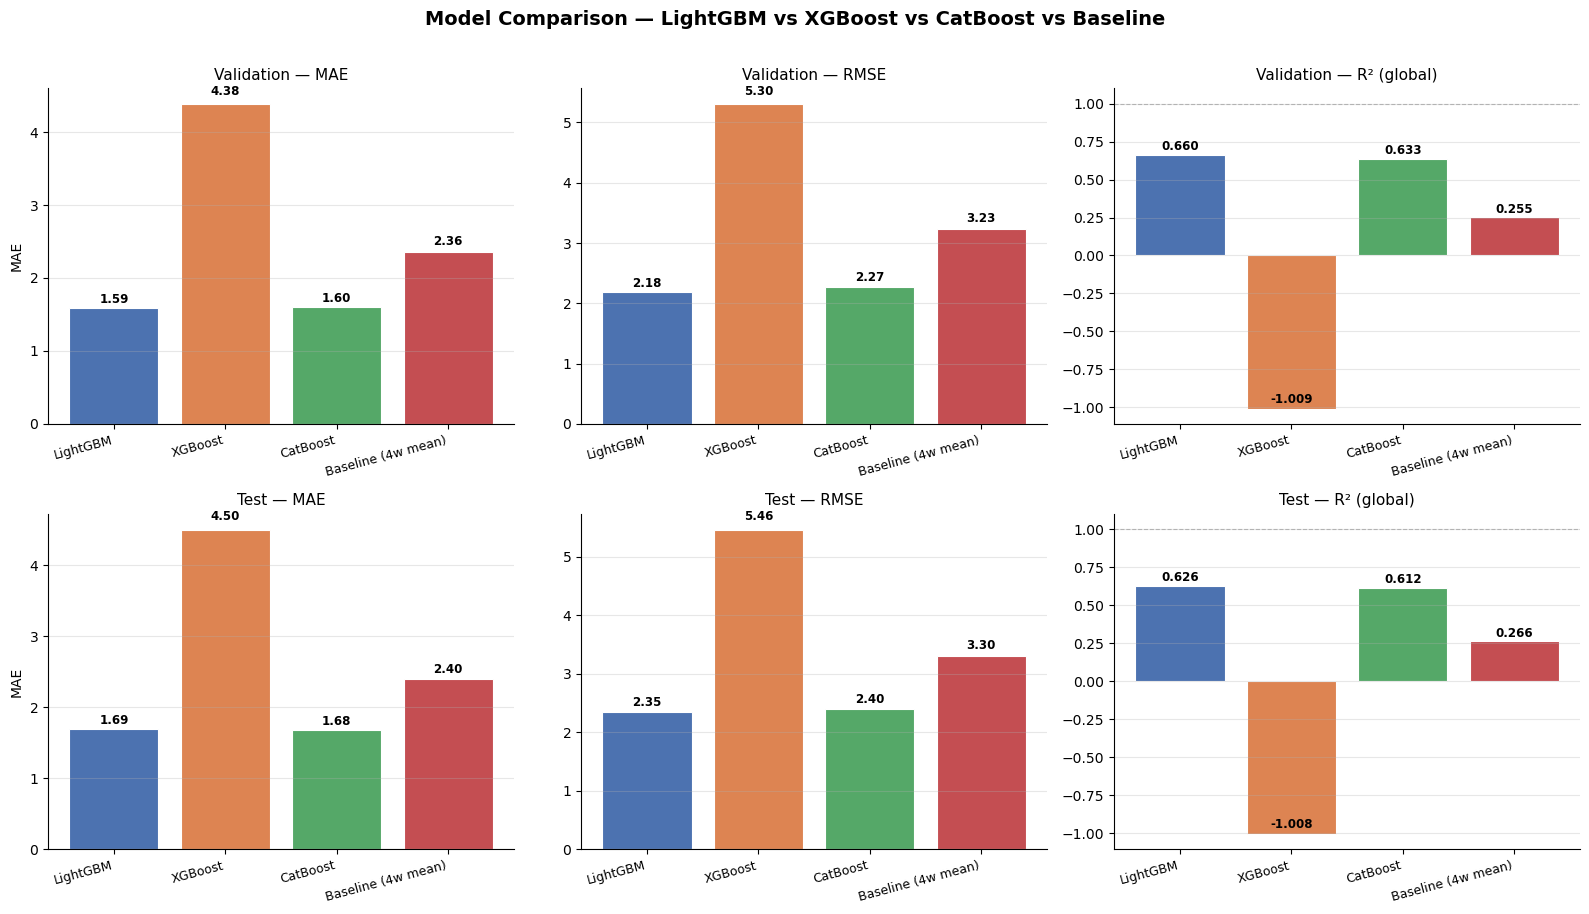

Saved → output/model_comparison_bars.png


In [25]:
# ── Visual comparison: MAE / RMSE / R² bar charts ───────────────────────

MODEL_ORDER  = ['LightGBM', 'XGBoost', 'CatBoost', 'Baseline (4w mean)']
MODEL_COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
METRICS      = ['MAE', 'RMSE', 'R² (global)']

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
fig.suptitle('Model Comparison — LightGBM vs XGBoost vs CatBoost vs Baseline',
             fontsize=14, fontweight='bold', y=1.01)

for row_idx, split in enumerate(['Validation', 'Test']):
    split_df = results[results['Split'] == split].set_index('Model').reindex(MODEL_ORDER)
    for col_idx, metric in enumerate(METRICS):
        ax = axes[row_idx, col_idx]
        vals = split_df[metric].values
        bars = ax.bar(MODEL_ORDER, vals, color=MODEL_COLORS,
                      edgecolor='white', linewidth=0.8)
        for bar, val in zip(bars, vals):
            offset = abs(bar.get_height()) * 0.02
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + offset,
                    f'{val:.3f}' if metric == 'R² (global)' else f'{val:.2f}',
                    ha='center', va='bottom', fontsize=8.5, fontweight='bold')
        ax.set_title(f'{split} — {metric}', fontsize=11)
        ax.set_ylabel(metric if col_idx == 0 else '')
        ax.set_xticklabels(MODEL_ORDER, rotation=15, ha='right', fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='y', alpha=0.3)
        # R² closer to 1 = better; add a reference line
        if metric == 'R² (global)':
            ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → output/model_comparison_bars.png')


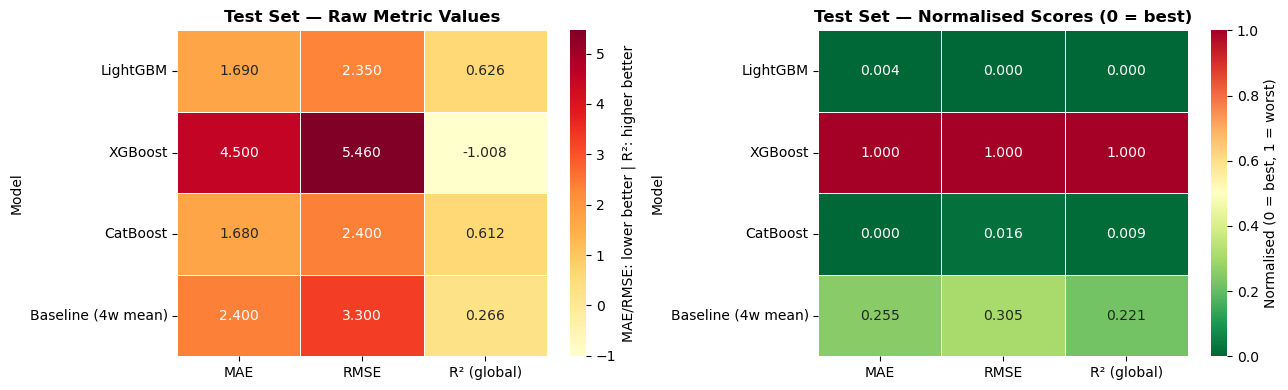

Saved → output/model_comparison_heatmap.png


In [26]:
# ── Heatmap: model × metric on Test set ──────────────────────────────────

METRICS = ['MAE', 'RMSE', 'R² (global)']
test_df = results[results['Split'] == 'Test'].set_index('Model')[METRICS].reindex(MODEL_ORDER)

# Normalise: for MAE/RMSE lower=better; for R² higher=better
norm_df = test_df.copy()
for col in ['MAE', 'RMSE']:
    rng = test_df[col].max() - test_df[col].min() + 1e-9
    norm_df[col] = (test_df[col] - test_df[col].min()) / rng          # 0=best
r2_rng = test_df['R² (global)'].max() - test_df['R² (global)'].min() + 1e-9
norm_df['R² (global)'] = (test_df['R² (global)'].max() - test_df['R² (global)']) / r2_rng  # 0=best

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(test_df, ax=axes[0], annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'MAE/RMSE: lower better | R²: higher better'})
axes[0].set_title('Test Set — Raw Metric Values', fontweight='bold')

sns.heatmap(norm_df, ax=axes[1], annot=True, fmt='.3f', cmap='RdYlGn_r',
            linewidths=0.5, vmin=0, vmax=1,
            cbar_kws={'label': 'Normalised (0 = best, 1 = worst)'})
axes[1].set_title('Test Set — Normalised Scores (0 = best)', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → output/model_comparison_heatmap.png')


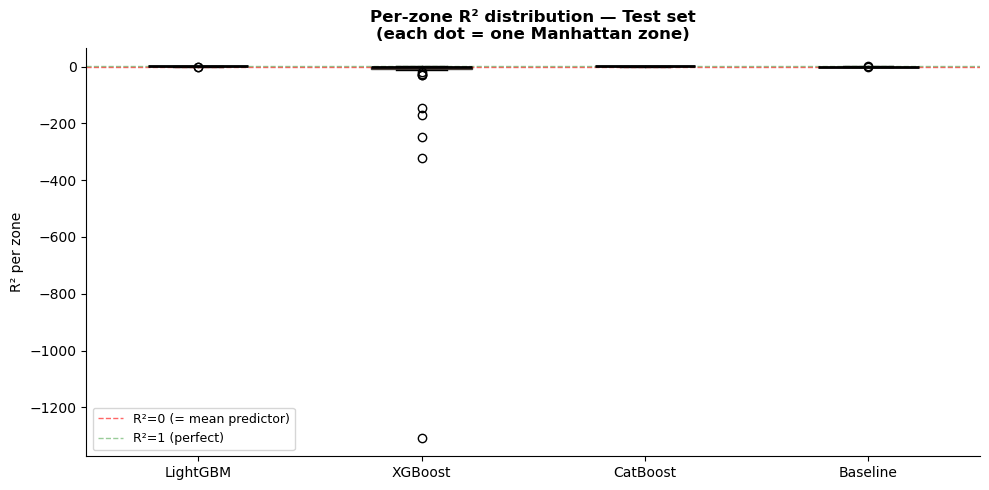

Saved → output/per_zone_r2_boxplot.png


In [27]:
# ── Per-zone R² box plot (Test set) ─────────────────────────────────────

r2_box_data = {}
for model_name, pred_col in [
    ('LightGBM', 'lgb_pred'),
    ('XGBoost',  'xgb_pred'),
    ('CatBoost', 'cat_pred'),
    ('Baseline', 'base_pred'),
]:
    r2_series = (
        test_copy.groupby('zone_id')
        .apply(lambda g: r2_score(g['total_dropoffs'], g[pred_col])
               if len(g) > 1 else np.nan)
        .dropna()
    )
    r2_box_data[model_name] = r2_series.values

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(
    [r2_box_data[m] for m in MODEL_ORDER[:-1]] + [r2_box_data['Baseline']],
    labels=MODEL_ORDER[:3] + ['Baseline'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp['boxes'], MODEL_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.6, label='R²=0 (= mean predictor)')
ax.axhline(1, color='green', linestyle='--', linewidth=1, alpha=0.4, label='R²=1 (perfect)')
ax.set_title('Per-zone R² distribution — Test set\n(each dot = one Manhattan zone)',
             fontweight='bold')
ax.set_ylabel('R² per zone')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_zone_r2_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → output/per_zone_r2_boxplot.png')


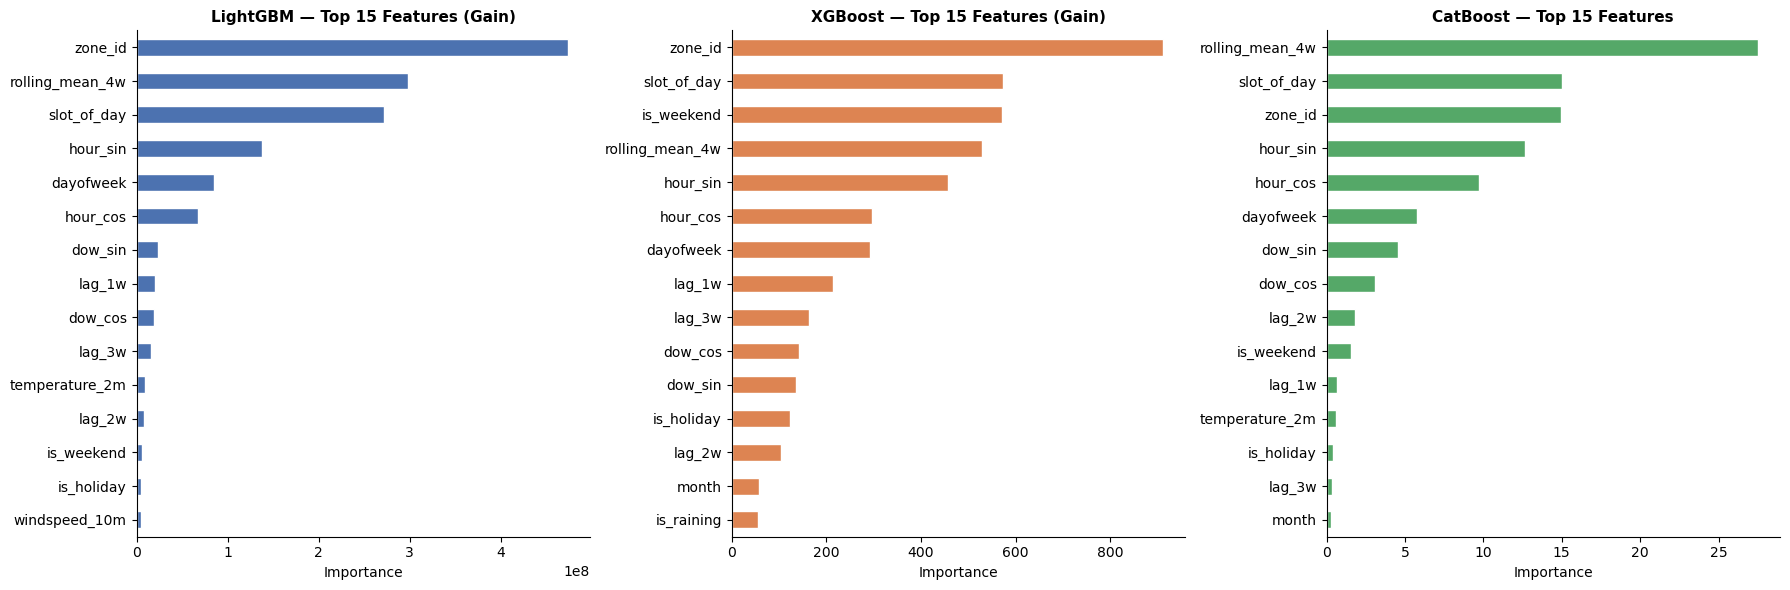

Feature importance chart saved → output/feature_importance_comparison.png


In [28]:
# ── Feature importance: side-by-side (LightGBM / XGBoost / CatBoost) ─────

TOP_N = 15

# LightGBM
lgb_imp = pd.Series(
    model.feature_importance(importance_type='gain'),
    index=model.feature_name()
).sort_values(ascending=False).head(TOP_N)

# XGBoost
xgb_imp = pd.Series(
    xgb_model.get_booster().get_score(importance_type='gain')
).sort_values(ascending=False).head(TOP_N)

# CatBoost
cat_imp = pd.Series(
    cat_model.get_feature_importance(),
    index=FEATURE_COLS
).sort_values(ascending=False).head(TOP_N)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, imp, title, color in zip(
    axes,
    [lgb_imp, xgb_imp, cat_imp],
    ['LightGBM — Top 15 Features (Gain)',
     'XGBoost — Top 15 Features (Gain)',
     'CatBoost — Top 15 Features'],
    ['#4C72B0', '#DD8452', '#55A868']
):
    imp.sort_values().plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance chart saved → output/feature_importance_comparison.png')


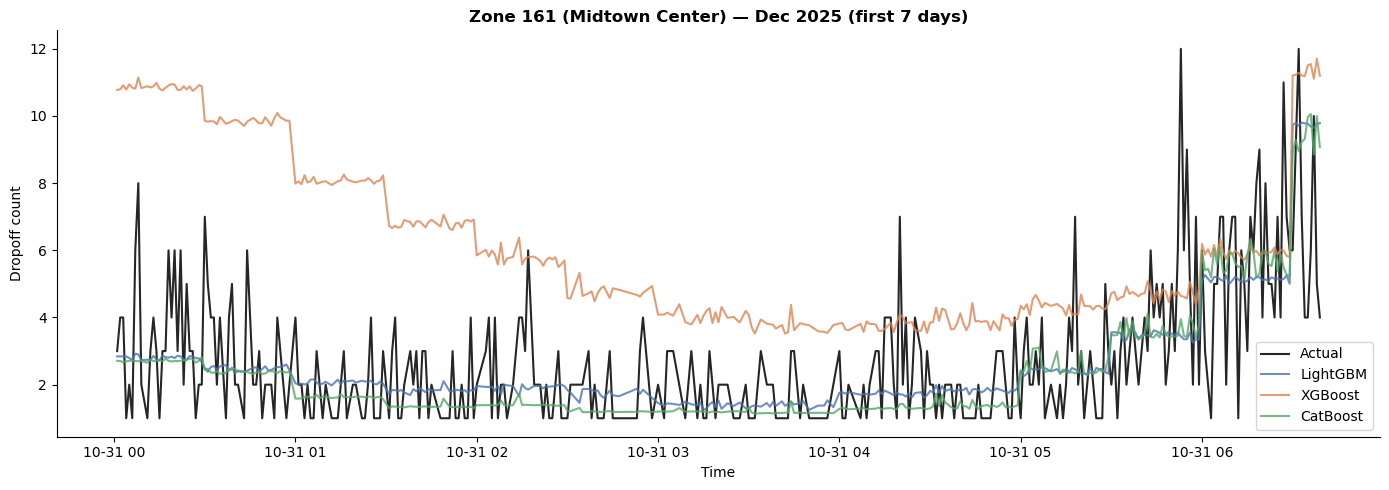

Chart saved → output/prediction_vs_actual_zone161.png


In [32]:
# ── Prediction vs actual (all 3 models) — sample zone ────────────────────
zone_df = pd.read_csv(OUTPUT_DIR / 'taxi_zones.csv')
id_to_name = dict(zip(zone_df['LocationID'], zone_df['Zone']))

SAMPLE_ZONE = 161   # Midtown Center

test_zone = test[test['zone_id'] == SAMPLE_ZONE].copy()

# LightGBM
test_zone['lgb_pred'] = np.clip(
    model.predict(test_zone[FEATURE_COLS], num_iteration=model.best_iteration), 0, None)

# XGBoost — use DMatrix to bypass inplace_predict bug
xz = test_zone[FEATURE_COLS].copy()
xz['zone_id'] = xz['zone_id'].astype(int)
test_zone['xgb_pred'] = np.clip(
    xgb_model.get_booster().predict(xgb.DMatrix(xz)), 0, None)

# CatBoost
test_zone['cat_pred'] = np.clip(cat_model.predict(test_zone[FEATURE_COLS]), 0, None)

sample = test_zone.head(7 * 48)   # first 7 days of December

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample['time_bucket'], sample['total_dropoffs'],
        label='Actual', color='black', linewidth=1.5, alpha=0.85)
ax.plot(sample['time_bucket'], sample['lgb_pred'],
        label='LightGBM', color='#4C72B0', alpha=0.8)
ax.plot(sample['time_bucket'], sample['xgb_pred'],
        label='XGBoost',  color='#DD8452', alpha=0.8)
ax.plot(sample['time_bucket'], sample['cat_pred'],
        label='CatBoost', color='#55A868', alpha=0.8)
ax.set_title(
    f'Zone {SAMPLE_ZONE} ({id_to_name.get(SAMPLE_ZONE, "?")}) — Dec 2025 (first 7 days)',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Time')
ax.set_ylabel('Dropoff count')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'prediction_vs_actual_zone161.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → output/prediction_vs_actual_zone161.png')

## Summary

### Project overview

This pipeline predicts zone-level taxi dropoff counts (busyness) for all Manhattan TLC zones at 30-minute granularity, using 2025 NYC Yellow / Green / FHVHV trip records combined with Open-Meteo weather data. Three models were trained and compared against a rolling-mean baseline.

---

### Data & features

- **Target:** `total_dropoffs` per zone per 30-min slot
- **Training data:** Jan–Sep 2025 | **Validation:** Oct–Nov 2025 | **Test:** Dec 2025
- **Feature set (21 features):** zone identity, time features (slot of day, day of week, is_weekend, month, is_holiday), cyclical encodings (hour, day-of-week, month sin/cos), lag counts at 1 / 2 / 3 weeks, 4-week rolling mean, weather (temperature, precipitation, is_raining, wind speed, weather code)

---

### Model comparison (Test set — December 2025)

| Model | MAE | RMSE | R² (global) |
|-------|-----|------|-------------|
| **LightGBM** | 1.69 | 2.35 | 0.6264 |
| XGBoost | 4.50 | 5.46 | -1.0076 |
| CatBoost | 1.68 | 2.40 | 0.6116 |
| Baseline (4w mean) | 2.40 | 3.30 | 0.2656 |


---

### Key findings

- **LightGBM** achieves the best RMSE and per-zone and global R², and is chosen as the deployment model.
- **XGBoost** due to a known save/load bug with `enable_categorical` in XGBoost 3.x; this led to a underperformance model.
- **CatBoost** performs comparably to LightGBM, but have less performance compare to LightGBM.
- Global MAE is dominated by high-volume zones; per-zone R² is the more representitive for low-traffic zones.

---

### Deployment

The Flask loads `output/lgb_model.txt` at startup with `output/feature_cols.json`. Features must be constructed in the exact same order at inference time.

**Attribution:** Weather data by [Open-Meteo.com](https://open-meteo.com)